# Experiment 2 — Positivity-Preserving Analysis of Geometric Brownian Motion

**Euler–Maruyama vs Milstein on the price process** · Problem 4 (Direction 4), the Optional ☆☆☆ "positivity" task

## The model

Geometric Brownian motion (GBM) is the benchmark asset-price model

$$
\mathrm{d}S_t = \mu\, S_t\,\mathrm{d}t + \sigma\, S_t\,\mathrm{d}W_t, \qquad S(0)=S_0>0,
$$

whose exact (strong) solution is

$$
S(t) = S_0\exp\!\Big(\big(\mu-\tfrac12\sigma^2\big)t + \sigma\,W(t)\Big).
$$

Because $S(t)$ is a **lognormal** random variable, it is strictly positive for every $t\ge 0$. A numerical
scheme is called *positivity-preserving* if it shares this property: a negative sample $S_n<0$ is a purely
numerical artefact.

## The two schemes (discretising the *price* $S$ directly)

The problem pack asks us to discretise the price itself (not the log-price), so that the noise $\sigma S$ is
state-dependent and the strong orders ($\tfrac12$ for EM, $1$ for Milstein) can be measured:

$$
S_{n+1} = S_n + \mu S_n \Delta t + \sigma S_n \Delta W_n
\qquad\qquad \text{(Euler–Maruyama, EM)}
$$

$$
S_{n+1} = S_n + \mu S_n \Delta t + \sigma S_n \Delta W_n + \tfrac12\sigma^2 S_n\big(\Delta W_n^2-\Delta t\big)
\qquad \text{(Milstein)}
$$

with $\Delta W_n=\sqrt{\Delta t}\,Z_n$, $Z_n\overset{\text{iid}}{\sim}\mathcal N(0,1)$.

## This notebook

1. **Analyses** exactly when a single EM or Milstein update can turn negative, and derives the per-step and
   per-path negativity probabilities as functions of $\Delta t$.
2. **Illustrates** the failure regions on the standard-normal density and on the Milstein parabola.
3. **Experiments**: a Monte-Carlo measurement of the negativity rate vs $\Delta t$, a negative-path vs
   exact-path plot, and the effect of negative samples on **European option prices**.

> **A note on parameters.** With the benchmark parameters $(\mu=0.05,\ \sigma=0.20)$ negativity is practically
> unobservable (EM $\sim e^{-1/(2\sigma^2\Delta t)}$, Milstein *never* negative). We therefore run the
> experiments in a **stress-test regime** $(\mu=0.05,\ \sigma=2.0)$ so the effect is visible — see §3 below. This is
> a deliberately unrealistic setting chosen to *expose* the phenomenon, not a market-calibration recommendation.


In [1]:
import os
import sys

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from scipy.stats import norm
from IPython.display import display, Markdown

# Make the repo's `code` package importable.  __file__ is undefined inside a
# notebook, so locate the project root by walking up from the current working
# directory (the notebook's folder) until we find the code/__init__.py marker.
_ROOT = os.getcwd()
for _ in range(6):
    if os.path.isfile(os.path.join(_ROOT, "code", "__init__.py")):
        break
    _ROOT = os.path.dirname(_ROOT)
_PROJECT_ROOT = os.path.abspath(_ROOT)
if _PROJECT_ROOT not in sys.path:
    sys.path.insert(0, _PROJECT_ROOT)

# The repo package is named `code`, which collides with Python's stdlib `code`
# module — and IPython pre-imports the stdlib one.  Drop it so `import code`
# below resolves to the repo package instead of the standard library.
sys.modules.pop("code", None)

from code.SDEs import bm_engine     # Brownian-increment engine
from code.solvers import em, milstein

%matplotlib inline
plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 150,
    "axes.grid": True,
    "grid.linestyle": ":",
    "grid.alpha": 0.5,
    "legend.fontsize": "small",
})

FIGURES_DIR = os.path.join(_PROJECT_ROOT, "figures")
os.makedirs(FIGURES_DIR, exist_ok=True)

# ---- parameters -----------------------------------------------------------
S0     = 100.0     # initial price (does not affect the sign analysis)
MU     = 0.05      # drift (kept from the benchmark)
T      = 1.0       # horizon
SIGMA  = 2.0       # <-- stress-test volatility (10x the benchmark 0.20)
DT_C   = 1.0 / (SIGMA**2 - 2.0 * MU)   # Milstein positivity threshold

print("Milstein positivity threshold  dt_c = 1/(sigma^2 - 2 mu) = %.6f" % DT_C)


Milstein positivity threshold  dt_c = 1/(sigma^2 - 2 mu) = 0.256410


## 1. Euler–Maruyama: when can one step go negative?

The EM update factors as

$$
S_{n+1} = S_n\left(1 + \mu\,\Delta t + \sigma\sqrt{\Delta t}\,Z_n\right).
$$

If $S_n>0$, the next value is negative exactly when the *bracket* is negative:

$$
1 + \mu\,\Delta t + \sigma\sqrt{\Delta t}\,Z_n \le 0
\quad\Longleftrightarrow\quad
Z_n \le -\frac{1+\mu\,\Delta t}{\sigma\sqrt{\Delta t}} \;=:\; -a(\Delta t).
$$

Since $Z_n\sim\mathcal N(0,1)$, the **per-step** probability of producing a negative value is

$$
\boxed{\;p_{\mathrm{EM}}(\Delta t) = \Phi\!\left(-\frac{1+\mu\,\Delta t}{\sigma\sqrt{\Delta t}}\right)
\;\sim\; \exp\!\left(-\frac{1}{2\sigma^2\Delta t}\right)\quad\text{as }\Delta t\to 0.\;}
$$

Two facts matter for the *whole path*:

* The sign of $S_{n+1}$ equals $\operatorname{sign}(S_n)\cdot\operatorname{sign}(\text{bracket})$: the bracket's sign
  is **independent of** $S_n$.  Starting from $S_0>0$, $S$ first becomes negative at the first step whose bracket is negative.
* The brackets are independent across steps, so with $n=T/\Delta t$ steps the **path-level** probabilities are

$$
\mathbb P\!\left(\min_{0\le m\le n} S_m < 0\right) = 1-(1-p_{\mathrm{EM}})^n,
\qquad
\mathbb P\!\left(S_T < 0\right) = \frac{1-(1-2p_{\mathrm{EM}})^n}{2}.
$$

The second identity counts the event "an odd number of brackets are negative" (each negative bracket flips
the sign; an even number restores it).

**Key point.** For *any* $\Delta t>0$ the threshold $-a(\Delta t)$ is a finite negative number, so
$p_{\mathrm{EM}}(\Delta t)>0$: EM is **never** positivity-preserving, only *asymptotically* so (the probability
vanishes faster than any power of $\Delta t$).


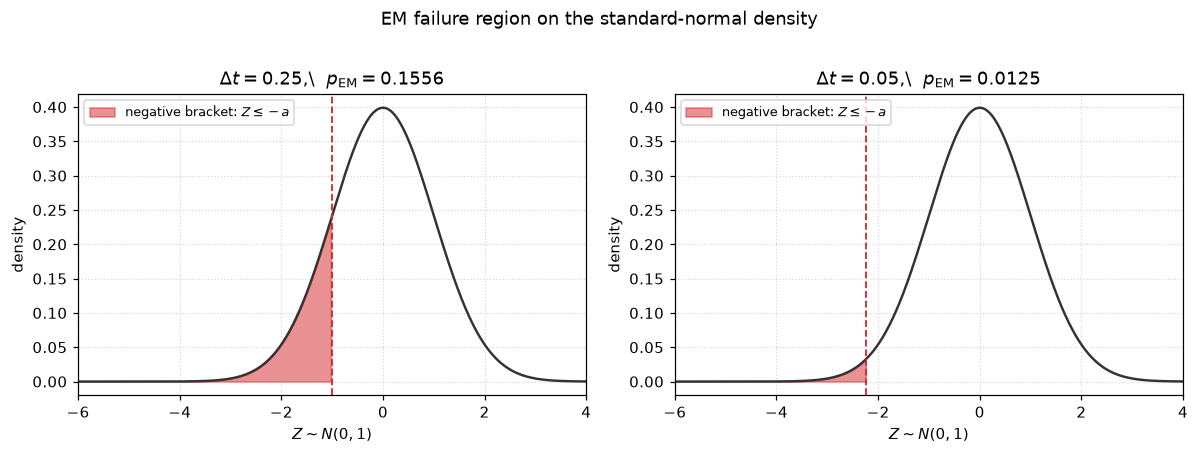

In [2]:
# Illustration: where in the Z ~ N(0,1) distribution does an EM step go negative?
z = np.linspace(-6, 4, 600)
pdf = norm.pdf(z)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.0))
for ax, dt in zip(axes, [0.25, 0.05]):
    a = (1.0 + MU * dt) / (SIGMA * np.sqrt(dt))          # Z <= -a  causes negativity
    ax.plot(z, pdf, color="0.2", lw=1.6)
    ax.fill_between(z, 0, pdf, where=(z <= -a), color="C3", alpha=0.5,
                    label=r"negative bracket: $Z\leq -a$")
    ax.axvline(-a, color="C3", ls="--", lw=1.2)
    ax.set_title(r"$\Delta t=%.2f$,\  $p_{\mathrm{EM}}=%.4f$" % (dt, norm.cdf(-a)))
    ax.set_xlabel(r"$Z\sim N(0,1)$")
    ax.set_ylabel("density")
    ax.legend()
    ax.set_xlim(-6, 4)

fig.suptitle("EM failure region on the standard-normal density", y=1.02)
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "exp2_em_tail.png"), dpi=150, bbox_inches="tight")
plt.show()


## 2. Milstein: when can one step go negative?

The Milstein update factors as

$$
S_{n+1} = S_n\,g(Z_n), \qquad
g(z) = \underbrace{\frac{\sigma^2\Delta t}{2}}_{a}\,z^2
      + \underbrace{\sigma\sqrt{\Delta t}}_{b}\,z
      + \underbrace{\Big[1+\big(\mu-\tfrac12\sigma^2\big)\Delta t\Big]}_{c}.
$$

$g$ is an **upward-opening parabola** ($a>0$), so it is negative exactly on the interval between its two roots,
*if* those roots exist. The value at the vertex and the discriminant are

$$
g_{\min} = c - \frac{b^2}{4a} = \tfrac12 + \big(\mu-\tfrac12\sigma^2\big)\Delta t,
\qquad
D = b^2-4ac = \sigma^2\Delta t\Big[(\sigma^2-2\mu)\Delta t - 1\Big].
$$

There are two regimes:

**Case (a) — positivity guaranteed.** If $D\le 0$ — i.e. $\sigma^2-2\mu\le 0$, or
$\Delta t \le \dfrac{1}{\sigma^2-2\mu}$ when $\sigma^2>2\mu$ — then $g(z)\ge 0$ for **all** $z$, so a Milstein step
can **never** produce a negative value: Milstein is positivity-preserving in this regime.

**Case (b) — positivity fails.** If $\sigma^2>2\mu$ *and* $\Delta t > \dfrac{1}{\sigma^2-2\mu}$, then $D>0$ and
$g(z)<0$ exactly for $z$ between the roots

$$
z_{1,2} = \frac{-1 \mp \sqrt{(\sigma^2-2\mu)\Delta t - 1}}{\sigma\sqrt{\Delta t}},
$$

so the per-step negativity probability is

$$
\boxed{\;p_{\mathrm{Mil}}(\Delta t) = \Phi(z_2)-\Phi(z_1)\;}.
$$

> **Benchmark remark.** With $\sigma=0.20,\ \mu=0.05$ we have $\sigma^2-2\mu=-0.06<0$, so
> $g_{\min}=\tfrac12+0.03\Delta t>0$ and Milstein is positivity-preserving for *every* $\Delta t$ — which is why a
> stress-test $\sigma$ is needed to observe Case (b).


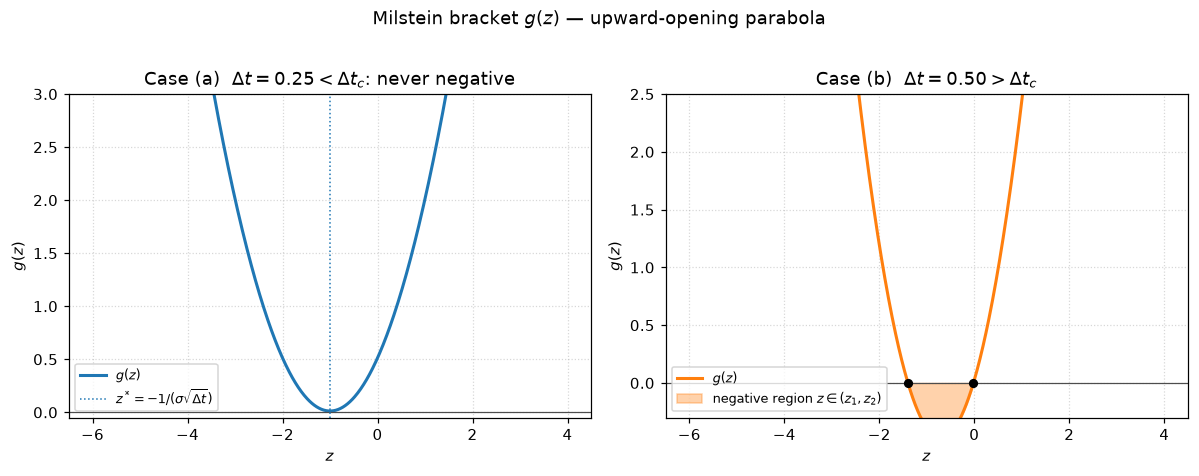

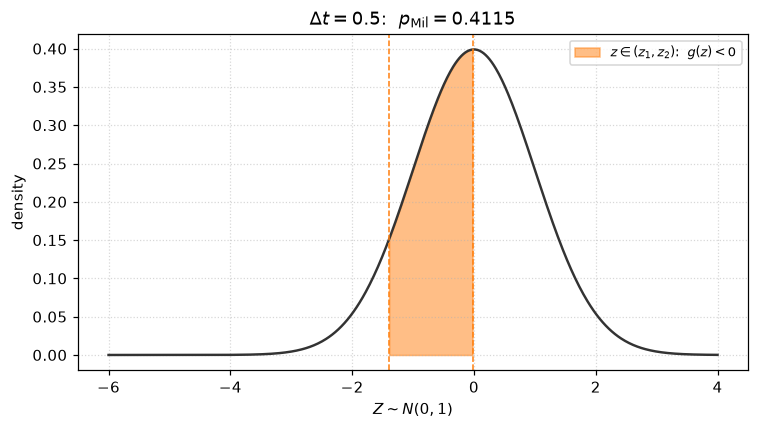

In [3]:
def milstein_roots(dt, mu=MU, sigma=SIGMA):
    '''Roots of the Milstein bracket g(z); empty array if D <= 0.'''
    d = (sigma**2 - 2.0 * mu) * dt - 1.0
    if d <= 0:
        return np.array([])
    return np.array([(-1.0 - np.sqrt(d)) / (sigma * np.sqrt(dt)),
                     (-1.0 + np.sqrt(d)) / (sigma * np.sqrt(dt))])


def milstein_g(z, dt, mu=MU, sigma=SIGMA):
    '''Milstein bracket g(z) = (sigma^2 dt / 2) z^2 + sigma sqrt(dt) z + [1 + (mu - sigma^2/2) dt].'''
    return (0.5 * sigma**2 * dt) * z**2 + (sigma * np.sqrt(dt)) * z + (1.0 + (mu - 0.5 * sigma**2) * dt)


z = np.linspace(-6, 4, 800)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

# Case (a): dt below threshold -> parabola never touches the axis
dt_a = 0.25
ax = axes[0]
ax.plot(z, milstein_g(z, dt_a), color="C0", lw=2, label="$g(z)$")
ax.axhline(0, color="0.3", lw=0.8)
ax.axvline(-1.0 / (SIGMA * np.sqrt(dt_a)), color="C0", ls=":", lw=1,
           label=r"$z^*=-1/(\sigma\sqrt{\Delta t})$")
ax.set_title(r"Case (a)  $\Delta t=%.2f < \Delta t_c$: never negative" % dt_a)
ax.set_xlabel("$z$"); ax.set_ylabel("$g(z)$"); ax.legend()
ax.set_ylim(-0.05, 3.0)

# Case (b): dt above threshold -> parabola dips below 0 between the roots
dt_b = 0.5
r1, r2 = milstein_roots(dt_b)
ax = axes[1]
ax.plot(z, milstein_g(z, dt_b), color="C1", lw=2, label="$g(z)$")
ax.axhline(0, color="0.3", lw=0.8)
ax.fill_between(z, milstein_g(z, dt_b), 0,
                where=((z >= r1) & (z <= r2)), color="C1", alpha=0.35,
                label=r"negative region $z\in(z_1,z_2)$")
ax.plot([r1, r2], [0, 0], "ko", ms=5)
ax.set_title(r"Case (b)  $\Delta t=%.2f > \Delta t_c$" % dt_b)
ax.set_xlabel("$z$"); ax.set_ylabel("$g(z)$"); ax.legend()
ax.set_ylim(-0.3, 2.5)

fig.suptitle(r"Milstein bracket $g(z)$ — upward-opening parabola", y=1.02)
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "exp2_milstein_parabola.png"), dpi=150, bbox_inches="tight")
plt.show()

# The same failure region, viewed on the distribution of Z ~ N(0,1)
z = np.linspace(-6, 4, 600)
pdf = norm.pdf(z)
r1, r2 = milstein_roots(0.5)
p_mil = norm.cdf(r2) - norm.cdf(r1)

fig, ax = plt.subplots(figsize=(7, 4.0))
ax.plot(z, pdf, color="0.2", lw=1.6)
ax.fill_between(z, 0, pdf, where=((z >= r1) & (z <= r2)), color="C1", alpha=0.5,
                label=r"$z\in(z_1,z_2)$:  $g(z)<0$")
ax.axvline(r1, color="C1", ls="--", lw=1)
ax.axvline(r2, color="C1", ls="--", lw=1)
ax.set_title(r"$\Delta t=0.5$:  $p_{\mathrm{Mil}}=%.4f$" % p_mil)
ax.set_xlabel(r"$Z\sim N(0,1)$")
ax.set_ylabel("density")
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "exp2_milstein_tail.png"), dpi=150, bbox_inches="tight")
plt.show()


## 3. Parameter selection: why the stress test?

The sign of $S_{n+1}$ is **independent of $S_0$** (every update is multiplicative), so $S_0=100$ and $T=1$ are
kept from the benchmark; only $\mu$ and $\sigma$ drive the negativity analysis.

**Benchmark regime** $(\mu=0.05,\ \sigma=0.20)$:

* EM: $p_{\mathrm{EM}}(\Delta t)=\Phi\!\big(-\frac{1+0.05\Delta t}{0.2\sqrt{\Delta t}}\big)$. Even at $\Delta t=1$,
  $\Phi(-5.25)\approx 7\times 10^{-8}$ — far below any Monte-Carlo resolution.
* Milstein: $\sigma^2-2\mu=-0.06<0$ $\Rightarrow$ **never** negative for any $\Delta t$.

Nothing is observable, so the benchmark is a poor illustration of the phenomenon (which is itself the point: in
realistic settings negativity is irrelevant).

**Stress-test regime** $(\mu=0.05,\ \sigma=2.0)$:

$$
\sigma^2-2\mu = 3.9 > 0
\qquad\Longrightarrow\qquad
\Delta t_c = \frac{1}{\sigma^2-2\mu} \approx 0.2564 .
$$

Now the Milstein threshold sits inside a convenient $\Delta t$ grid and EM's per-step probability is large enough
to resolve. $\sigma=2.0$ is a $10\times$ blow-up of the benchmark volatility — a deliberate stress test used only to
*expose* the mechanism.


In [4]:
dt_c = 1.0 / (SIGMA**2 - 2.0 * MU)
print("stress:  sigma^2 - 2 mu = %.3f  ->  dt_c = %.5f" % (SIGMA**2 - 2 * MU, dt_c))

print("\nEM per-step negativity  p_EM(dt) = Phi(-(1 + mu dt) / (sigma sqrt(dt)))")
for dt in [1.0, 0.5, 1/3, 0.25, 0.2, 0.1, 0.05, 0.02]:
    p = norm.cdf(-(1.0 + MU * dt) / (SIGMA * np.sqrt(dt)))
    print("  dt=%5.3f  p_EM=%.3e" % (dt, p))

print("\nMilstein per-step negativity  p_Mil(dt)   (0 whenever dt <= dt_c)")
for dt in [1.0, 0.5, 1/3, 0.25, 0.2, 0.1, 0.05, 0.02]:
    r = milstein_roots(dt)
    p = norm.cdf(r[1]) - norm.cdf(r[0]) if r.size else 0.0
    print("  dt=%5.3f  p_Mil=%.4f" % (dt, p))

print("\nbenchmark sigma=0.20 for comparison:")
print("  EM   p_EM(1.0) = %.3e" % norm.cdf(-(1.0 + 0.05 * 1.0) / (0.20 * np.sqrt(1.0))))
print("  Milstein        = 0 for all dt  (sigma^2 - 2 mu = %.2f < 0)" % (0.20**2 - 2 * 0.05))


stress:  sigma^2 - 2 mu = 3.900  ->  dt_c = 0.25641

EM per-step negativity  p_EM(dt) = Phi(-(1 + mu dt) / (sigma sqrt(dt)))
  dt=1.000  p_EM=2.998e-01
  dt=0.500  p_EM=2.343e-01
  dt=0.333  p_EM=1.893e-01
  dt=0.250  p_EM=1.556e-01
  dt=0.200  p_EM=1.294e-01
  dt=0.100  p_EM=5.603e-02
  dt=0.050  p_EM=1.249e-02
  dt=0.020  p_EM=2.008e-04

Milstein per-step negativity  p_Mil(dt)   (0 whenever dt <= dt_c)
  dt=1.000  p_Mil=0.5491
  dt=0.500  p_Mil=0.4115
  dt=0.333  p_Mil=0.2576
  dt=0.250  p_Mil=0.0000
  dt=0.200  p_Mil=0.0000
  dt=0.100  p_Mil=0.0000
  dt=0.050  p_Mil=0.0000
  dt=0.020  p_Mil=0.0000

benchmark sigma=0.20 for comparison:
  EM   p_EM(1.0) = 7.605e-08
  Milstein        = 0 for all dt  (sigma^2 - 2 mu = -0.06 < 0)


In [5]:
def run_mc(dt, M, seed):
    '''Monte-Carlo negativity statistics for one dt.

    Returns a dict with, for EM and Milstein:
      *_p     per-step bracket-negativity rate  (matches the theory p(dt))
      *_ever  fraction of paths that ever go negative on [0, T]
    The loop is memory-safe: only the (M, n) increment array is materialised.
    '''
    n = int(round(T / dt))
    dW = bm_engine.standard_bm(n, dt, M, seed=seed)      # (M, n)

    S_em = np.full(M, S0);  ever_em = np.zeros(M, bool)
    S_mi = np.full(M, S0);  ever_mi = np.zeros(M, bool)
    neg_em = 0;  neg_mi = 0

    for k in range(n):
        d = dW[:, k]
        # per-step bracket negativity (direct, independent of the path state)
        neg_em += int((1.0 + MU * dt + SIGMA * d < 0).sum())
        neg_mi += int((1.0 + (MU - 0.5 * SIGMA**2) * dt + SIGMA * d + 0.5 * SIGMA**2 * d * d < 0).sum())
        # actual stepping -> path-level "ever negative"
        S_em = em.em_step("gbm", S_em, dt, d, mu=MU, sigma=SIGMA)
        S_mi = milstein.milstein_step("gbm", S_mi, dt, d, mu=MU, sigma=SIGMA)
        ever_em |= (S_em < 0)
        ever_mi |= (S_mi < 0)

    return dict(em_p=neg_em / (M * n), mil_p=neg_mi / (M * n),
                em_ever=ever_em.mean(), mil_ever=ever_mi.mean())


In [6]:
# Experiment A — Monte-Carlo negativity vs dt (stress regime)
M = 1_000_000
grid_n = [1, 2, 3, 4, 5, 10, 20, 50]          # dt = 1 / n

rows = []
for n in grid_n:
    dt = 1.0 / n
    r = run_mc(dt, M, seed=1234 + n)
    p_em_th = norm.cdf(-(1.0 + MU * dt) / (SIGMA * np.sqrt(dt)))
    rts = milstein_roots(dt)
    p_mi_th = norm.cdf(rts[1]) - norm.cdf(rts[0]) if rts.size else 0.0
    ever_em_th = 1.0 - (1.0 - p_em_th) ** n
    ever_mi_th = 1.0 - (1.0 - p_mi_th) ** n
    rows.append((dt, n, p_em_th, r["em_p"], ever_em_th, r["em_ever"],
                 p_mi_th, r["mil_p"], ever_mi_th, r["mil_ever"]))

# per-step table
t1 = "| $\\Delta t$ | $n$ | EM $p$ (th) | EM $p$ (MC) | Mil $p$ (th) | Mil $p$ (MC) |\n"
t1 += "|---:|---:|---:|---:|---:|---:|\n"
for dt, n, ept, epm, eet, eem, mpt, mpm, met, mem in rows:
    t1 += "| %.3f | %d | %.4f | %.4f | %.4f | %.4f |\n" % (dt, n, ept, epm, mpt, mpm)

# path-level table
t2 = "| $\\Delta t$ | $n$ | EM $\\mathbb P(\\min S<0)$ (th) | (MC) | Mil (th) | Mil (MC) |\n"
t2 += "|---:|---:|---:|---:|---:|---:|\n"
for dt, n, ept, epm, eet, eem, mpt, mpm, met, mem in rows:
    t2 += "| %.3f | %d | %.4f | %.4f | %.4f | %.4f |\n" % (dt, n, eet, eem, met, mem)

display(Markdown("**Per-step bracket negativity** $p(\\Delta t)$ (theory vs Monte-Carlo):\n\n" + t1))
display(Markdown("**Path-level** $\\mathbb P(\\min_{m\\le n} S_m<0)$ (theory vs Monte-Carlo):\n\n" + t2))
print("(M = %d paths; MC std error on p ~ %.1e for p = 0.2)" % (M, np.sqrt(0.2 * 0.8 / M)))


**Per-step bracket negativity** $p(\Delta t)$ (theory vs Monte-Carlo):

| $\Delta t$ | $n$ | EM $p$ (th) | EM $p$ (MC) | Mil $p$ (th) | Mil $p$ (MC) |
|---:|---:|---:|---:|---:|---:|
| 1.000 | 1 | 0.2998 | 0.3002 | 0.5491 | 0.5492 |
| 0.500 | 2 | 0.2343 | 0.2343 | 0.4115 | 0.4115 |
| 0.333 | 3 | 0.1893 | 0.1894 | 0.2576 | 0.2574 |
| 0.250 | 4 | 0.1556 | 0.1559 | 0.0000 | 0.0000 |
| 0.200 | 5 | 0.1294 | 0.1294 | 0.0000 | 0.0000 |
| 0.100 | 10 | 0.0560 | 0.0560 | 0.0000 | 0.0000 |
| 0.050 | 20 | 0.0125 | 0.0125 | 0.0000 | 0.0000 |
| 0.020 | 50 | 0.0002 | 0.0002 | 0.0000 | 0.0000 |


**Path-level** $\mathbb P(\min_{m\le n} S_m<0)$ (theory vs Monte-Carlo):

| $\Delta t$ | $n$ | EM $\mathbb P(\min S<0)$ (th) | (MC) | Mil (th) | Mil (MC) |
|---:|---:|---:|---:|---:|---:|
| 1.000 | 1 | 0.2998 | 0.3002 | 0.5491 | 0.5492 |
| 0.500 | 2 | 0.4137 | 0.4138 | 0.6537 | 0.6537 |
| 0.333 | 3 | 0.4672 | 0.4673 | 0.5908 | 0.5908 |
| 0.250 | 4 | 0.4917 | 0.4923 | 0.0000 | 0.0000 |
| 0.200 | 5 | 0.4999 | 0.5000 | 0.0000 | 0.0000 |
| 0.100 | 10 | 0.4382 | 0.4384 | 0.0000 | 0.0000 |
| 0.050 | 20 | 0.2223 | 0.2219 | 0.0000 | 0.0000 |
| 0.020 | 50 | 0.0100 | 0.0099 | 0.0000 | 0.0000 |


(M = 1000000 paths; MC std error on p ~ 4.0e-04 for p = 0.2)


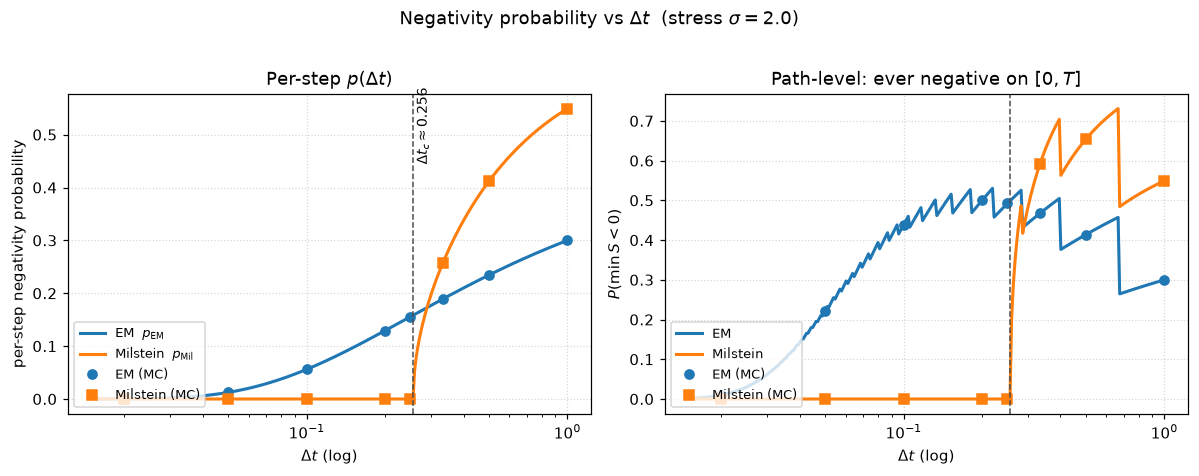

In [7]:
# Experiment B — negativity probability vs dt (theory curves + empirical markers)
dt_grid = np.array([1.0, 0.5, 1/3, 0.25, 0.2, 0.1, 0.05, 0.02])
dt_dense = np.logspace(np.log10(0.015), 0.0, 300)

def p_em(dt):
    return norm.cdf(-(1.0 + MU * dt) / (SIGMA * np.sqrt(dt)))

def p_mil(dt):
    d = (SIGMA**2 - 2.0 * MU) * dt - 1.0
    out = np.zeros_like(dt)
    ok = d > 0
    r1 = (-1.0 - np.sqrt(d[ok])) / (SIGMA * np.sqrt(dt[ok]))
    r2 = (-1.0 + np.sqrt(d[ok])) / (SIGMA * np.sqrt(dt[ok]))
    out[ok] = norm.cdf(r2) - norm.cdf(r1)
    return out

# empirical values from Experiment A
em_p_mc   = np.array([r[3] for r in rows])
mil_p_mc  = np.array([r[7] for r in rows])
em_ev_mc  = np.array([r[5] for r in rows])
mil_ev_mc = np.array([r[9] for r in rows])

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

# left: per-step bracket negativity p(dt)
ax = axes[0]
ax.semilogx(dt_dense, p_em(dt_dense), color="C0", lw=2, label=r"EM  $p_{\mathrm{EM}}$")
ax.semilogx(dt_dense, p_mil(dt_dense), color="C1", lw=2, label=r"Milstein  $p_{\mathrm{Mil}}$")
ax.semilogx(dt_grid, em_p_mc, "o", color="C0", ms=6, label="EM (MC)")
ax.semilogx(dt_grid, mil_p_mc, "s", color="C1", ms=6, label="Milstein (MC)")
ax.axvline(DT_C, color="0.3", ls="--", lw=1)
ax.text(DT_C * 1.03, 0.45, r"$\Delta t_c\approx0.256$", rotation=90, fontsize=9)
ax.set_xlabel(r"$\Delta t$ (log)")
ax.set_ylabel("per-step negativity probability")
ax.set_title(r"Per-step $p(\Delta t)$")
ax.legend(loc="lower left"); ax.grid(True, ls=":", alpha=0.5)

# right: path-level P(ever negative over [0,T])
n_dense = (1.0 / dt_dense).round()
ax = axes[1]
ax.semilogx(dt_dense, 1.0 - (1.0 - p_em(dt_dense)) ** n_dense, color="C0", lw=2, label="EM")
ax.semilogx(dt_dense, 1.0 - (1.0 - p_mil(dt_dense)) ** n_dense, color="C1", lw=2, label="Milstein")
ax.semilogx(dt_grid, em_ev_mc, "o", color="C0", ms=6, label="EM (MC)")
ax.semilogx(dt_grid, mil_ev_mc, "s", color="C1", ms=6, label="Milstein (MC)")
ax.axvline(DT_C, color="0.3", ls="--", lw=1)
ax.set_xlabel(r"$\Delta t$ (log)")
ax.set_ylabel(r"$P(\min S<0)$")
ax.set_title(r"Path-level: ever negative on $[0,T]$")
ax.legend(loc="lower left"); ax.grid(True, ls=":", alpha=0.5)

fig.suptitle(r"Negativity probability vs $\Delta t$  (stress $\sigma=2.0$)", y=1.02)
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "exp2_negativity_vs_dt.png"), dpi=150, bbox_inches="tight")
plt.show()


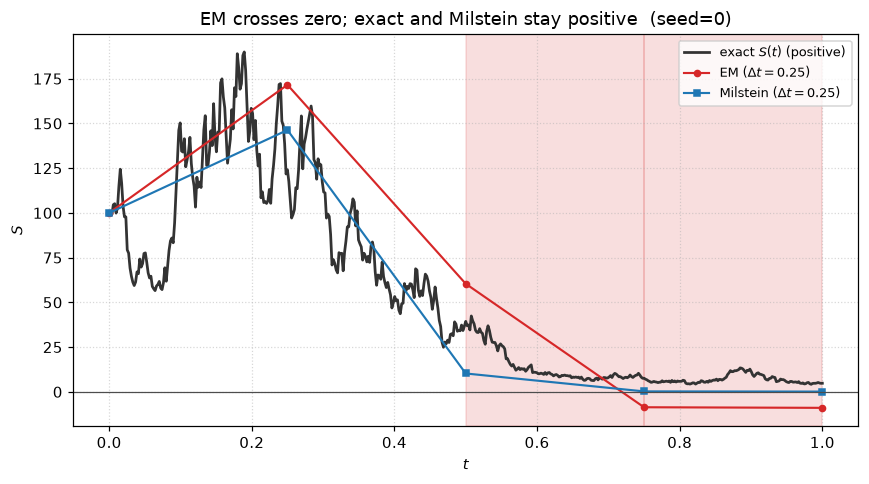

seed=0  |  min EM=-8.944   min Milstein=0.136   min exact=4.212


In [8]:
# Experiment C — a path where EM goes negative while exact & Milstein stay positive
n_fine = 512
dt_fine = T / n_fine
n_coarse = 4                       # dt = 0.25  (< dt_c: Milstein stays positive)
dt_coarse = T / n_coarse

def exact_path(W_fine):
    t = dt_fine * np.arange(n_fine + 1)
    return S0 * np.exp((MU - 0.5 * SIGMA**2) * t + SIGMA * W_fine)

def coarse_run(dW_fine, n):
    dW = bm_engine.extract_dw(dW_fine, n)      # (n,) increments, same BM path
    S_em = S0;  S_mi = S0
    em_path = [S0];  mi_path = [S0]
    for k in range(n):
        S_em = em.em_step("gbm", S_em, T / n, dW[k], mu=MU, sigma=SIGMA)
        S_mi = milstein.milstein_step("gbm", S_mi, T / n, dW[k], mu=MU, sigma=SIGMA)
        em_path.append(S_em);  mi_path.append(S_mi)
    return np.array(em_path), np.array(mi_path)

# search a few seeds for a path where EM dips negative (exact is always positive)
for seed in range(60):
    dW_fine = bm_engine.standard_bm(n_fine, dt_fine, 1, seed=seed)[0]
    W_fine = np.concatenate([[0.0], np.cumsum(dW_fine)])
    em_path, mi_path = coarse_run(dW_fine, n_coarse)
    if em_path.min() < 0:
        break

S_ex = exact_path(W_fine)
t_ex = dt_fine * np.arange(n_fine + 1)
t_co = dt_coarse * np.arange(n_coarse + 1)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(t_ex, S_ex, color="0.2", lw=1.8, label=r"exact $S(t)$ (positive)")
ax.plot(t_co, em_path, "o-", color="C3", lw=1.4, ms=4, label=r"EM ($\Delta t=0.25$)")
ax.plot(t_co, mi_path, "s-", color="C0", lw=1.4, ms=4, label=r"Milstein ($\Delta t=0.25$)")
ax.axhline(0, color="0.3", lw=0.8)
neg = em_path < 0
if neg.any():
    for i in range(n_coarse):
        if neg[i] or neg[i + 1]:
            ax.axvspan(t_co[i], t_co[i + 1], color="C3", alpha=0.15)
ax.set_xlabel("$t$"); ax.set_ylabel("$S$")
ax.set_title("EM crosses zero; exact and Milstein stay positive  (seed=%d)" % seed)
ax.legend(); ax.grid(True, ls=":", alpha=0.5)
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "exp2_negative_path.png"), dpi=150, bbox_inches="tight")
plt.show()

print("seed=%d  |  min EM=%.3f   min Milstein=%.3f   min exact=%.3f"
      % (seed, em_path.min(), mi_path.min(), S_ex.min()))


## 4. Effect on option prices

A negative sample $S_n<0$ is **not** part of the true GBM law (which is lognormal, hence positive). Its practical
impact depends on how the payoff uses $S$:

* **European put** — payoff $(K-S_T)^+$ is *unbounded* as $S_T$ decreases, so a negative $S_T$ inflates the put
  price above its true value. This is the most visible bias.
* **European call** — payoff $(S_T-K)^+$ is zero whenever $S_T<0$, so negative samples contribute nothing
  *directly*; the bias enters only through the distorted tail of the (already wrong) EM distribution.
* **`log`-payoffs / Asian / barrier options** — any payoff requiring $\log S$ or a sign-dependent trigger is
  ill-defined or wrong once $S$ can cross zero, so a non-positivity-preserving scheme is unacceptable there.

To separate the **negativity** effect from the ordinary **discretisation** error, we price the put twice on the
*same* terminal samples: once with the raw (possibly negative) $S_T$, and once with negatives clamped to zero,
$\max(S_T,0)$. The difference
$$\mathbb E[(K-S_T)^+]-\mathbb E[(K-\max(S_T,0))^+]=\mathbb E\!\big[\,|S_T|\,\mathbf 1_{\{S_T<0\}}\big]$$
is exactly the extra money a put collects from a negative price — zero iff the scheme never goes negative. The call
is unchanged by this clamping ($(S_T-K)^+=0$ already whenever $S_T<0$), so its residual error is pure
discretisation. We compare each against the closed-form expectation on the *same* Brownian increments.


In [9]:
# Analytic expectation E[(S_T - K)^+] and E[(K - S_T)^+] for
#   S_T = S0 exp((mu - sigma^2/2) T + sigma sqrt(T) Z),  Z ~ N(0,1)
def eu_put_call(S0, K, T, mu, sigma):
    d1 = (np.log(S0 / K) + (mu + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    call = S0 * np.exp(mu * T) * norm.cdf(d1) - K * norm.cdf(d2)
    put  = K * norm.cdf(-d2) - S0 * np.exp(mu * T) * norm.cdf(-d1)
    return call, put

def simulate_terminal(dt, M, seed):
    '''Terminal S_T under EM / Milstein / exact on the SAME Brownian increments.'''
    n = int(round(T / dt))
    dW = bm_engine.standard_bm(n, dt, M, seed=seed)
    S_em = np.full(M, S0);  S_mi = np.full(M, S0);  S_ex = np.full(M, S0)
    for k in range(n):
        S_em = em.em_step("gbm", S_em, dt, dW[:, k], mu=MU, sigma=SIGMA)
        S_mi = milstein.milstein_step("gbm", S_mi, dt, dW[:, k], mu=MU, sigma=SIGMA)
        S_ex = S_ex * np.exp((MU - 0.5 * SIGMA**2) * dt + SIGMA * dW[:, k])
    return S_em, S_mi, S_ex

K = 100.0
call_ref, put_ref = eu_put_call(S0, K, T, MU, SIGMA)
print("Analytic expectation:  call E[(S_T-K)^+] = %.4f    put E[(K-S_T)^+] = %.4f\n" % (call_ref, put_ref))

# --- Put decomposition: isolate the negativity effect ---------------------
#   put_raw    = E[(K - S_T)^+]          negative S_T pay MORE than K
#   put_floor  = E[(K - max(S_T,0))^+]   negatives clamped to 0
#   gap = put_raw - put_floor = E[|S_T| 1(S_T<0)]  == pure negativity pollution
hdr = ["$\\Delta t$", "$n$", "scheme", "$\\mathbb P(S_T<0)$",
       "put (raw)", "put (floored)", "neg. gap", "put analytic"]
lines = ["| " + " | ".join(hdr) + " |",
         "|---:|---:|---:|---:|---:|---:|---:|---:|"]
for dt in [1.0, 0.5, 1/3, 0.25, 0.1]:
    n = int(round(T / dt))
    S_em, S_mi, S_ex = simulate_terminal(dt, M, seed=77)
    for name, S in [("EM", S_em), ("Milstein", S_mi), ("exact", S_ex)]:
        neg = float((S < 0).mean())
        put_raw = float(np.maximum(K - S, 0).mean())
        put_floor = float(np.maximum(K - np.maximum(S, 0), 0).mean())
        gap = put_raw - put_floor
        lines.append("| %.3f | %d | %s | %.4f | %.3f | %.3f | %.3f | %.3f |"
                     % (dt, n, name, neg, put_raw, put_floor, gap, put_ref))
display(Markdown("**Put decomposition** — the *neg. gap* column isolates the price impact of a negative $S_T$ "
                 "(equal to $\\mathbb E[|S_T|\\,\\mathbf 1_{\\{S_T<0\\}}]$):\n\n" + "\n".join(lines)))

# --- Calls: flooring negatives is a no-op, so only discretisation remains --
chdr = ["$\\Delta t$", "call EM", "call Milstein", "call exact", "call analytic"]
clines = ["| " + " | ".join(chdr) + " |", "|---:|---:|---:|---:|---:|"]
for dt in [1.0, 0.5, 1/3, 0.25, 0.1]:
    S_em, S_mi, S_ex = simulate_terminal(dt, M, seed=78)
    clines.append("| %.3f | %.3f | %.3f | %.3f | %.3f |"
                  % (dt, np.maximum(S_em - K, 0).mean(),
                     np.maximum(S_mi - K, 0).mean(),
                     np.maximum(S_ex - K, 0).mean(), call_ref))
display(Markdown("**Calls** — unaffected by flooring ($S_T<0$ already pays $0$); residual error is pure "
                 "discretisation, shrinking as $\\Delta t\\to 0$:\n\n" + "\n".join(clines)))


Analytic expectation:  call E[(S_T-K)^+] = 72.5981    put E[(K-S_T)^+] = 67.4710



**Put decomposition** — the *neg. gap* column isolates the price impact of a negative $S_T$ (equal to $\mathbb E[|S_T|\,\mathbf 1_{\{S_T<0\}}]$):

| $\Delta t$ | $n$ | scheme | $\mathbb P(S_T<0)$ | put (raw) | put (floored) | neg. gap | put analytic |
|---:|---:|---:|---:|---:|---:|---:|---:|
| 1.000 | 1 | EM | 0.3001 | 77.451 | 39.320 | 38.131 | 67.471 |
| 1.000 | 1 | Milstein | 0.5493 | 116.642 | 61.654 | 54.988 | 67.471 |
| 1.000 | 1 | exact | 0.0000 | 67.522 | 67.522 | 0.000 | 67.471 |
| 0.500 | 2 | EM | 0.3600 | 97.783 | 50.336 | 47.448 | 67.471 |
| 0.500 | 2 | Milstein | 0.4843 | 104.600 | 73.916 | 30.684 | 67.471 |
| 0.500 | 2 | exact | 0.0000 | 67.512 | 67.512 | 0.000 | 67.471 |
| 0.333 | 3 | EM | 0.3806 | 103.640 | 56.919 | 46.721 | 67.471 |
| 0.333 | 3 | Milstein | 0.4431 | 87.297 | 78.917 | 8.380 | 67.471 |
| 0.333 | 3 | exact | 0.0000 | 67.560 | 67.560 | 0.000 | 67.471 |
| 0.250 | 4 | EM | 0.3884 | 104.395 | 61.464 | 42.931 | 67.471 |
| 0.250 | 4 | Milstein | 0.0000 | 76.679 | 76.679 | 0.000 | 67.471 |
| 0.250 | 4 | exact | 0.0000 | 67.563 | 67.563 | 0.000 | 67.471 |
| 0.100 | 10 | EM | 0.3477 | 89.938 | 71.788 | 18.150 | 67.471 |
| 0.100 | 10 | Milstein | 0.0000 | 68.521 | 68.521 | 0.000 | 67.471 |
| 0.100 | 10 | exact | 0.0000 | 67.460 | 67.460 | 0.000 | 67.471 |

**Calls** — unaffected by flooring ($S_T<0$ already pays $0$); residual error is pure discretisation, shrinking as $\Delta t\to 0$:

| $\Delta t$ | call EM | call Milstein | call exact | call analytic |
|---:|---:|---:|---:|---:|
| 1.000 | 82.283 | 121.872 | 73.801 | 72.598 |
| 0.500 | 102.497 | 110.071 | 73.293 | 72.598 |
| 0.333 | 108.554 | 92.854 | 72.753 | 72.598 |
| 0.250 | 109.223 | 82.090 | 72.606 | 72.598 |
| 0.100 | 95.520 | 74.505 | 73.369 | 72.598 |

## 5. Conclusions

* **Euler–Maruyama is never positivity-preserving.** For any $\Delta t>0$ a step goes negative with probability
  $p_{\mathrm{EM}}(\Delta t)=\Phi\!\big(-\frac{1+\mu\Delta t}{\sigma\sqrt{\Delta t}}\big)>0$; it vanishes like
  $e^{-1/(2\sigma^2\Delta t)}$, so negativity is an asymptotic artefact that disappears only in the $\Delta t\to0$ limit.

* **Milstein has a hard threshold.** Writing the update bracket as the parabola
  $g(z)=\tfrac12\sigma^2\Delta t\,z^2+\sigma\sqrt{\Delta t}\,z+1+(\mu-\tfrac12\sigma^2)\Delta t$, its minimum is
  $\tfrac12+(\mu-\tfrac12\sigma^2)\Delta t$. Milstein is positivity-preserving for **all** $\Delta t$ whenever
  $\sigma^2\le 2\mu$ (the realistic benchmark), and for $\Delta t\le 1/(\sigma^2-2\mu)$ in the stress regime
  $\sigma^2>2\mu$. Above that threshold it can go negative with probability $\Phi(z_2)-\Phi(z_1)$.

* **Practical guidance.** For positivity-sensitive payoffs use the exact log-price simulator
  $S_{n+1}=S_n e^{(\mu-\sigma^2/2)\Delta t+\sigma\sqrt{\Delta t}Z_n}$ (positivity-preserving by construction), or
  Milstein in its safe regime. The negative samples of EM bias European **puts** upward (payoff unbounded as
  $S\to-\infty$) while leaving **calls** closer to exact (payoff is zero below $K$), and they outright break any
  $\log S$- or barrier-dependent contract.

* **Caveat.** Everything observable here uses the **stress-test** volatility $\sigma=2.0$ (ten times the benchmark).
  At the benchmark $\sigma=0.20$ the EM negativity probability is $\sim e^{-12.5/\Delta t}$ and Milstein never goes
  negative, so the phenomenon — while always present in principle — is numerically irrelevant in realistic GBM
  settings. That is precisely why a stress test was needed to *illustrate* it.
